_____
# Analysis on Interpretable Models: Full image - TFM
_____

The goal of the following notebook is to train several interpretable models using the outputs of the original CNN. Then decide which is the most useful one

## Load Modules

In [1]:
%load_ext autoreload
%autoreload 2

from utils.output_data import load_model_predictions_data, load_csv
from utils.interpretable_models import InterpretableModel, transform_inputs_labels_to_dataframe, transform_labels, compare_different_models, write_interpretability_linear

In [2]:
def _process_outputs_processed(outputs_processed):
    outputs_processed['prediction_label'] = outputs_processed.prediction_value.apply(lambda x : 0 if x < 0.5 else 1)
    outputs_processed['prediction_label_name'] = outputs_processed.prediction_label.apply(lambda x :  "Clase Control" if x == 0 else "Clase Paciente")
    
    X_columns = list(set(outputs_processed.columns).difference({"label", 'prediction_x', 'prediction_y', 'key', 'label_category', 'prediction_value', 'train_test' , "prediction_label", "prediction_label_name"}))
    y_columns = 'prediction_y'
    y_labels = 'label_category'

    # modify X columns
    X_columns = list(set(X_columns) - set({'HOG_feature_descriptor_power_density_of_max_fequency', 'HOG_feature_descriptor_entropy_frequency_domain', 'HOG_feature_descriptor_entropy',}))

    return (outputs_processed, X_columns, y_columns, y_labels )


## Load data

In [3]:
outputs_processed = load_csv("outputs_full_image_processed_model_trained_TrainTest.csv", "data/predictions/")


In [5]:
characteristics = [
    "Orientación de las fibras", "Intensidad media", "Intensidad mediana", "Moda de la intensidad", 
    "Número de agregados de colágeno", "Longitud de las fibras de colágeno", "Número de ramas de las fibras de colágeno", 
    "Circularidad de los núcleos", "Número de núcleos", "Dimensión fractal de las fibras de colágeno", 
    "Lagunaridad fractal", "Porosidad fractal", "Porosidad",  "Número de picos del VOG"
                   ]
equivalence = {
    "Orientación de las fibras": "Orientation", 
    "Intensidad media": "Intensity_Mean", 
    "Intensidad mediana": "Intensity_Median", 
    "Moda de la intensidad": "Intensity_Mode", 
    "Número de agregados de colágeno": "Aggregates", 
    "Longitud de las fibras de colágeno": "Branch_Length", 
    "Número de ramas de las fibras de colágeno": "Branch_Number", 
    "Circularidad de los núcleos": "Cell_Shape", 
    "Número de núcleos":"Number_of_Cells", 
    "Dimensión fractal de las fibras de colágeno": "Fractal_Dimension", 
    "Lagunaridad fractal": "Lacunarity" , 
    "Porosidad fractal": "Fractal_Porosity", 
    "Porosidad": "Porosity",
    "Número de picos del VOG" : "HOG_feature_descriptor_num_peaks", 
}

for eq in equivalence: 
    outputs_processed[eq] = outputs_processed[equivalence[eq]]

fields_selected = ["label", 'prediction_x', 'prediction_y', 'key', 'label_category', 'prediction_value', 'train_test' ]

selected_characteristics =[
    "Intensidad media",
    "Longitud de las fibras de colágeno",
    "Número de agregados de colágeno",
    "Orientación de las fibras", 
    "Porosidad",  
    "Número de picos del VOG"
    ]
outputs_processed["prediction_value"] = outputs_processed.prediction_y
data_copy = outputs_processed[fields_selected + selected_characteristics].copy()

outputs_processed,  X_columns, y_columns, y_labels = _process_outputs_processed(data_copy)

## Fit the models

### LINEAR REGRESSION

Report on: linear_regression using main threshold as 0.48
Train data: ---------
	Accuracy: 0.800
	Precision: 0.861
	Recall: 0.715
	F1: 0.782
	Specificity: 0.885

	AUC: 0.843
Test data: ---------
	Accuracy: 0.901
	Precision: 0.765
	Recall: 0.867
	F1: 0.812
	Specificity: 0.912

	AUC: 0.843


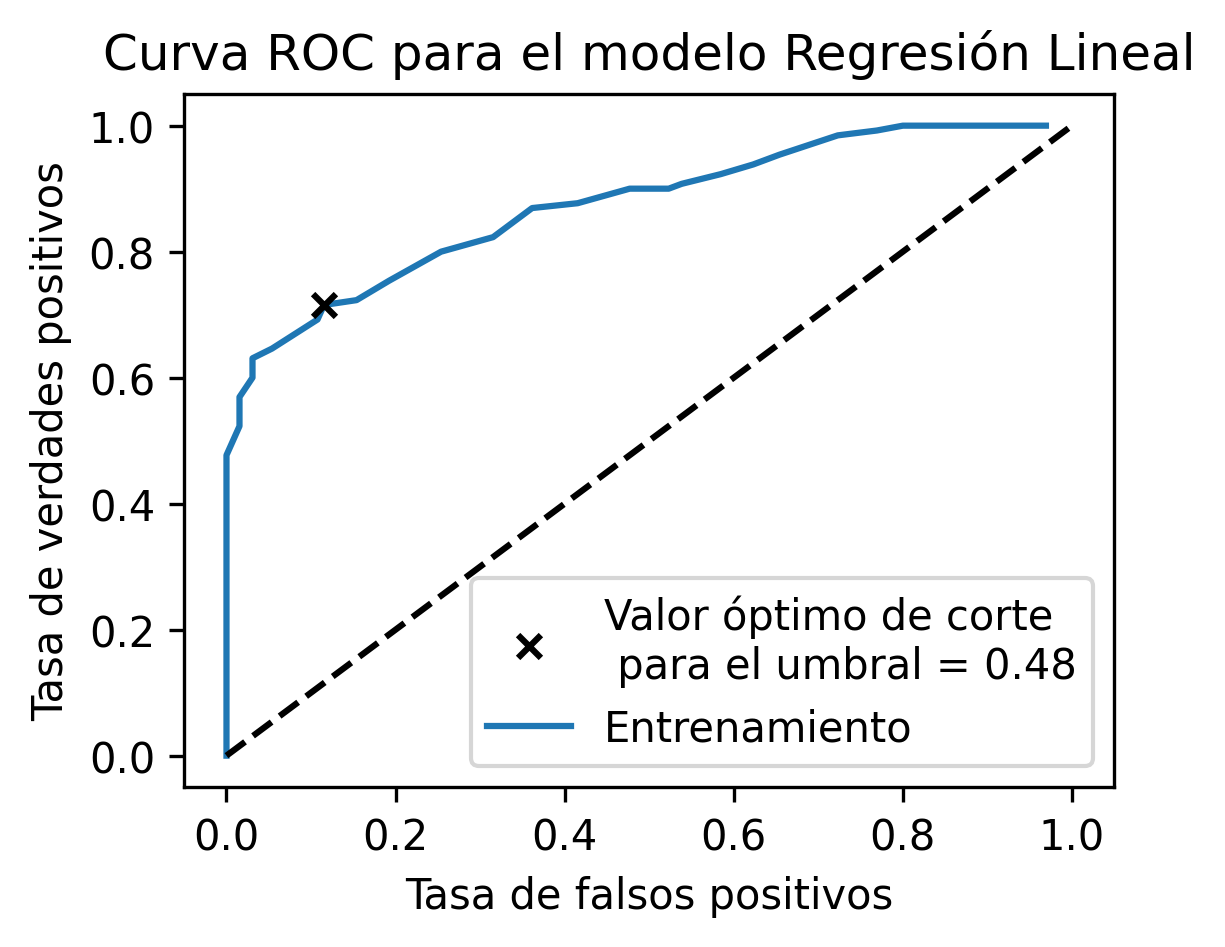

In [8]:
linear_regression = InterpretableModel("linear_regression", language = "spanish")
linear_regression.initiate_data(outputs_processed, X_columns, y_columns, y_labels)
linear_regression.fit()
linear_regression.predict()
linear_regression.evaluate()
linear_regression.wirte_report()

### DECISION TREE

/Users/robertplanas/.virtualenvs/tf/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/robertplanas/.virtualenvs/tf/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Report on: decision_tree using main threshold as 0.36
Train data: ---------
	Accuracy: 0.796
	Precision: 0.841
	Recall: 0.731
	F1: 0.782
	Specificity: 0.862

	AUC: 0.884
Test data: ---------
	Accuracy: 0.851
	Precision: 0.630
	Recall: 0.967
	F1: 0.763
	Specificity: 0.813

	AUC: 0.884


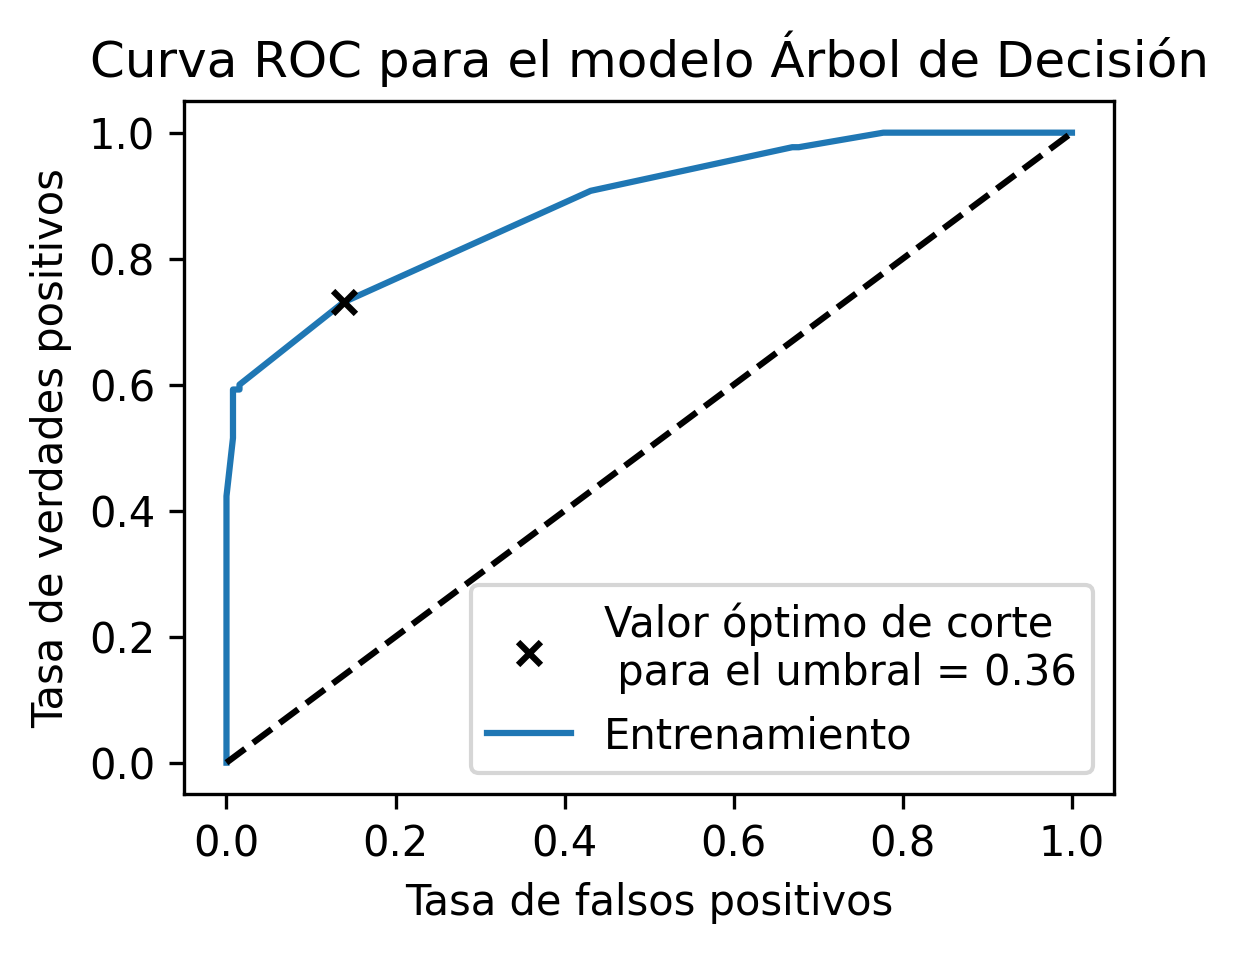

In [9]:
decision_tree = InterpretableModel("decision_tree", max_depth = 4, random_state = 0, language = "spanish")
decision_tree.initiate_data(outputs_processed, X_columns, y_columns, y_labels)
decision_tree.fit()
decision_tree.predict()
decision_tree.evaluate()
decision_tree.wirte_report()

# Compare the different models: 

In [15]:
# Linear regression
write_interpretability_linear(linear_regression.model.coef_, linear_regression.X_columns, intercept = linear_regression.model.intercept_ , model = linear_regression)

0.395 * ((-0.449 * Longitud de las fibras de colágeno) + (-0.0678 * Número de agregados de colágeno) + (0.265 * Intensidad media) + (0.122 * Orientación de las fibras) + (0.596 * Número de picos del HOG) + (-0.065 * Porosidad) + (-1.15e-16)) + 0.491


In [16]:
def compute_actual_value(value, std =decision_tree.standard_scaler_y.scale_[0], mean =  decision_tree.standard_scaler_y.mean_[0]): 
    return (value * std) + mean

In [17]:
compute_actual_value(1.041 )

0.9027106631075688

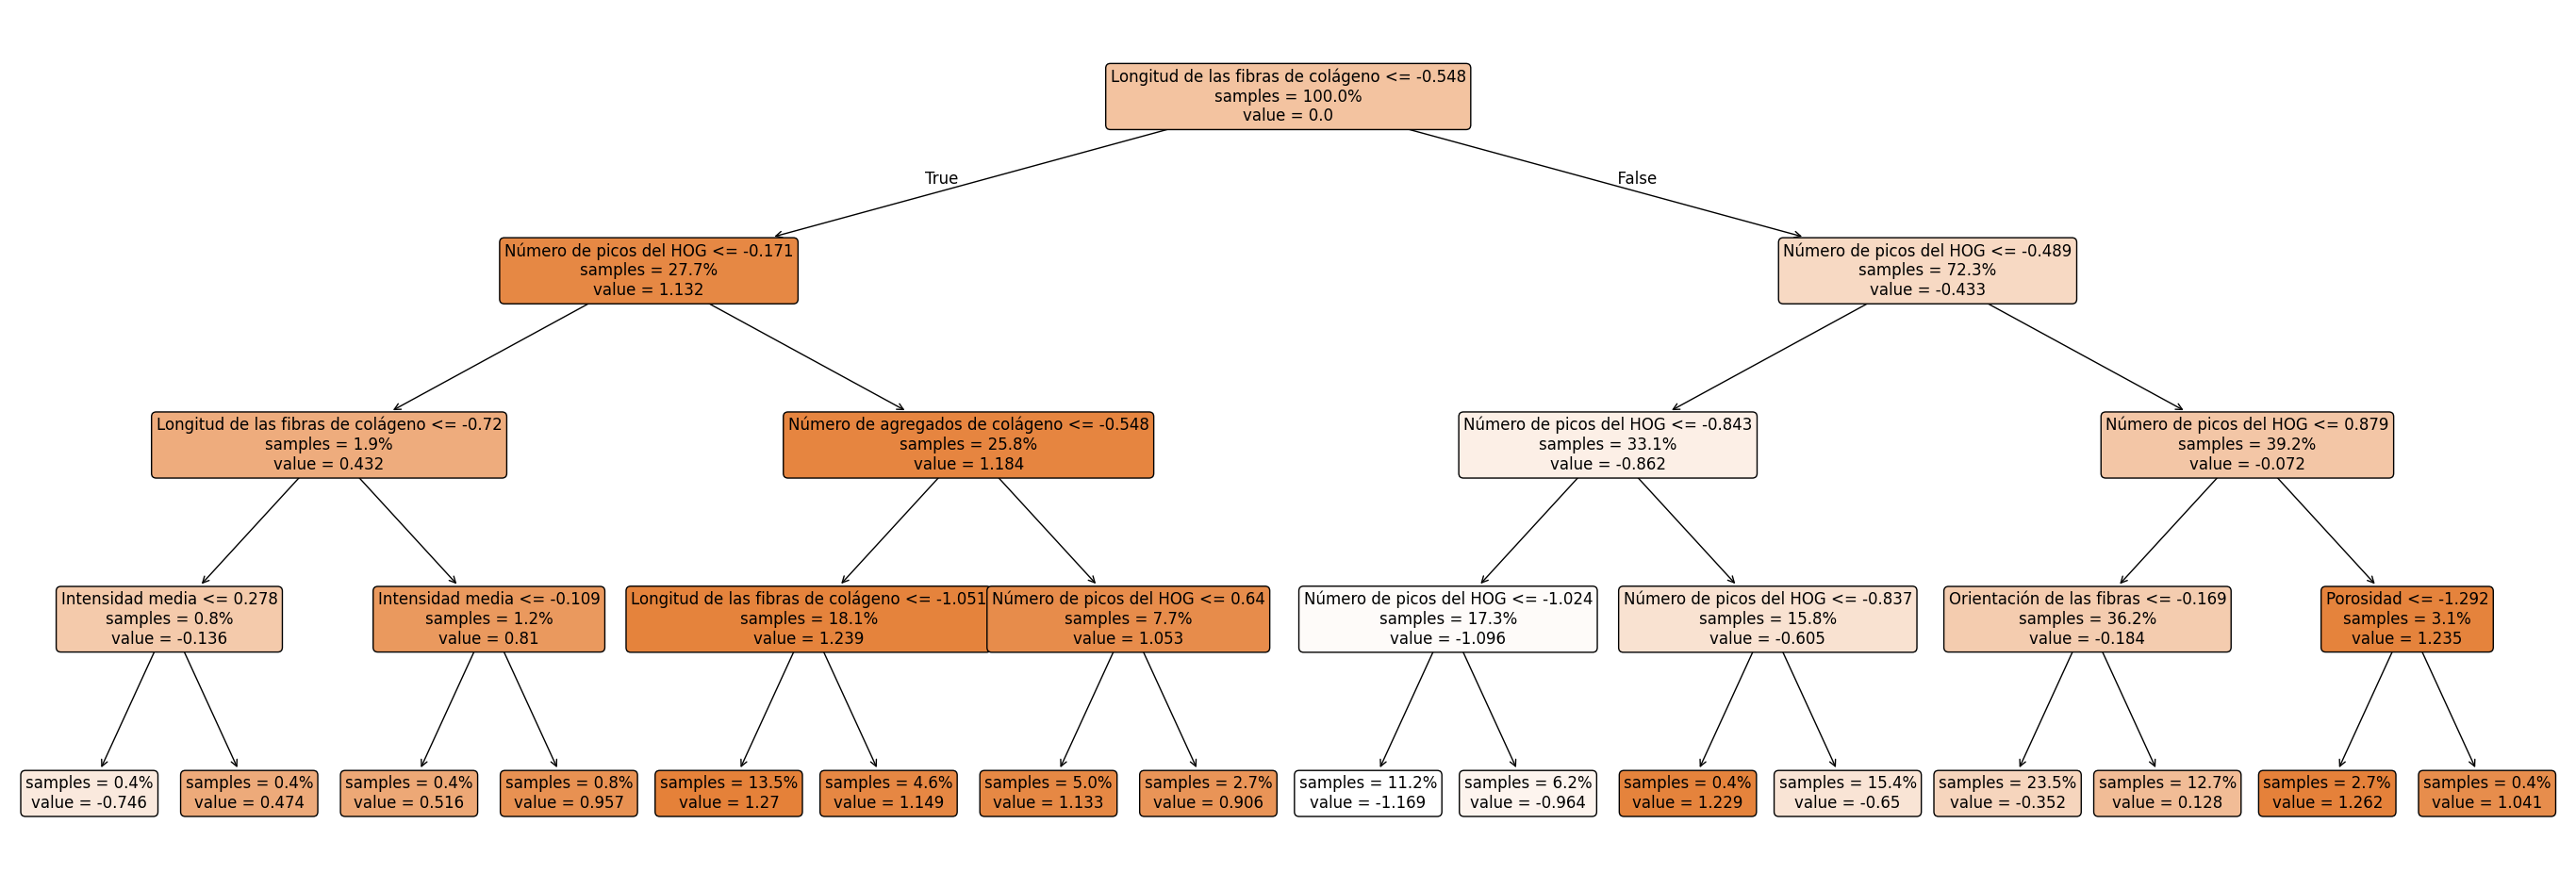

In [18]:
decision_tree.represent_decision_tree()

# Exaplin errors

In [19]:
from utils.output_data import load_csv
from utils.load_data import read_files_according_to_csv

In [20]:
from matplotlib import pyplot as plt

In [21]:
# Load data train test
images, names, labels = read_files_according_to_csv(
    "GT_pediatricos.csv", "data/database/original_database",
    images_paths=["data/database/original_database/CONTROL/", 
                  "data/database/original_database/PACIENTES/",],
)

INFO:utils.load_data: Loading images in 'data/database/original_database/CONTROL/'


INFO:utils.load_data: Loading images in 'data/database/original_database/PACIENTES/'


In [22]:
names

['171016_SJD15_F053_P1_01',
 '200212_SJD18_F004_P3_05',
 '180620_SJD15_F053_P1_02',
 '180620_SJD15_F053_P2_04',
 '200917_SJD18_F006_P2_01',
 '200212_SJD18_F004_P1_02',
 '201023_SJD18_F004_P1_02',
 '181212_SJD18_F004_P2_06',
 '181212_SJD18_F005_P6_01',
 '180614_SJD15_F053_P1_05',
 '171201_SJD15_F053_P2_01',
 '201023_SJD18_F004_P2_04',
 '180614_SJD15_F053_P2_03',
 '180209_SJD15_F053_P1_01',
 '190412_SJD15_F053_P2_05',
 '180511_SJD15_F053_P4_03',
 '190104_SJD18_F004_P3_04',
 '190412_SJD15_F053_P1_03',
 '200131_SJD18_F004_P3_01',
 '210714_SJD18_F004_P2_04',
 '171103_SJD17_F020_P2_05',
 '171123_SJD15_F053_P2_01',
 '190104_SJD18_F004_P2_05',
 '171103_SJD17_F020_P1_03',
 '210714_SJD18_F004_P1_02',
 '210714_SJD18_F004_P1_03',
 '171103_SJD17_F020_P1_02',
 '171103_SJD17_F020_P2_04',
 '190104_SJD18_F004_P2_04',
 '210714_SJD18_F004_P2_05',
 '190104_SJD18_F004_P3_05',
 '190412_SJD15_F053_P1_02',
 '200131_SJD18_F004_P2_01',
 '180511_SJD15_F053_P4_02',
 '190201_SJD18_F006_P1_01',
 '190412_SJD15_F053_

In [23]:
outputs_processed[(outputs_processed.label == "Control") & (outputs_processed.prediction_y < 0.5)]
control_predicted_patient = 85
control_predicted_control = 1

(-0.5, 1023.5, 1023.5, -0.5)

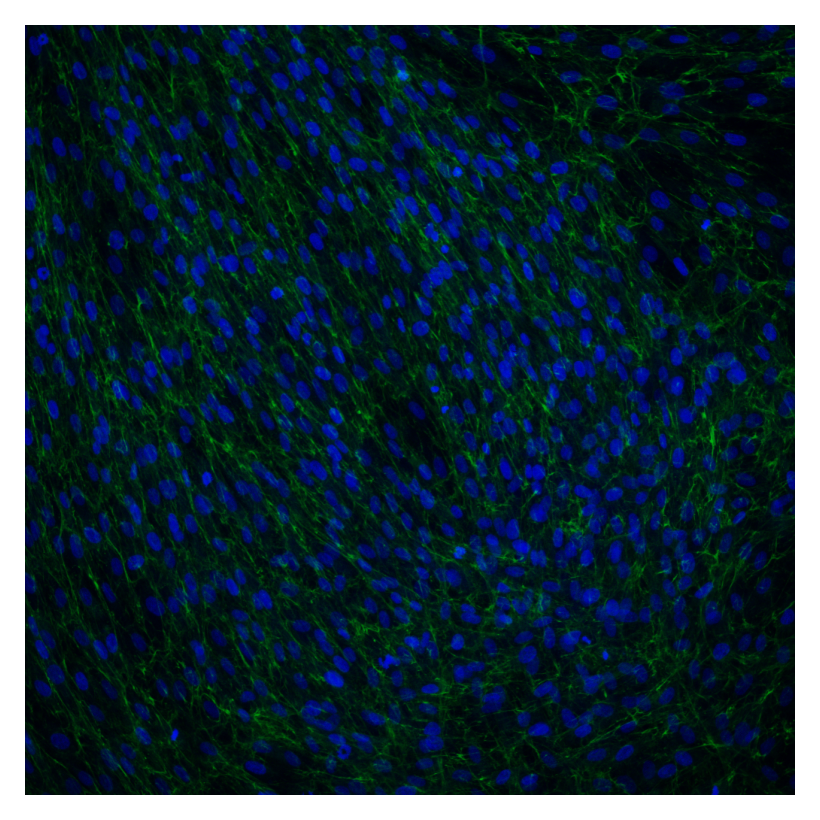

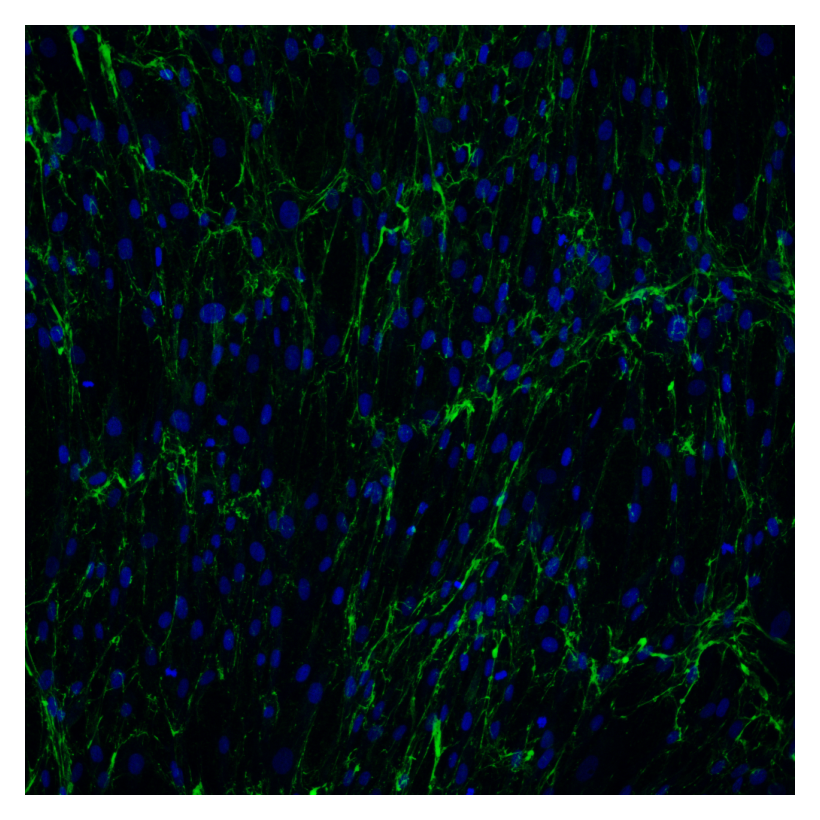

In [60]:
fig, axs = plt.subplots(1,1, figsize = (4,4), dpi = 250)
axs.imshow(images[control_predicted_control])
axs.axis("off")

fig, axs = plt.subplots(1,1, figsize = (4,4), dpi = 250)
axs.imshow(images[control_predicted_patient])
axs.axis("off")



In [41]:
x_sample_control_predicted_patient = outputs_processed.iloc[control_predicted_patient:control_predicted_patient+1][X_columns]
x_sample_control_predicted_control = outputs_processed.iloc[control_predicted_control:control_predicted_control+1][X_columns]

In [42]:
print("CONTROL PREDICTED PATIENT: ----")
linear_regression.predict_given_samples(x_sample_control_predicted_patient, verbose = True)
decision_tree.predict_given_samples(x_sample_control_predicted_patient, verbose = True)

print("CONTROL PREDICTED CONTROL : ----")

linear_regression.predict_given_samples(x_sample_control_predicted_control, verbose = True)
decision_tree.predict_given_samples(x_sample_control_predicted_control, verbose = True)

CONTROL PREDICTED PATIENT: ----
Longitud de las fibras de colágeno estandarizado: -0.808
Número de agregados de colágeno estandarizado: 0.197
Intensidad media estandarizado: -0.747
Orientación de las fibras estandarizado: 0.0313
Número de picos del HOG estandarizado: 0.416
Porosidad estandarizado: -0.86

Predicción: 0.673



Longitud de las fibras de colágeno estandarizado: -0.808
Número de agregados de colágeno estandarizado: 0.197
Intensidad media estandarizado: -0.747
Orientación de las fibras estandarizado: 0.0313
Número de picos del HOG estandarizado: 0.416
Porosidad estandarizado: -0.86

Predicción: 0.939



CONTROL PREDICTED CONTROL : ----
Longitud de las fibras de colágeno estandarizado: 1.64
Número de agregados de colágeno estandarizado: -0.635
Intensidad media estandarizado: 0.975
Orientación de las fibras estandarizado: -0.155
Número de picos del HOG estandarizado: -0.655
Porosidad estandarizado: 0.381

Predicción: 0.147



Longitud de las fibras de colágeno estandarizado: 1

array([[0.23392852]])

In [64]:
outputs_processed[(outputs_processed.label == "Leve") & (outputs_processed.prediction_y > 0.5)]
patient_predicted_control = 226
patient_predicted_patient = 243

(-0.5, 1023.5, 1023.5, -0.5)

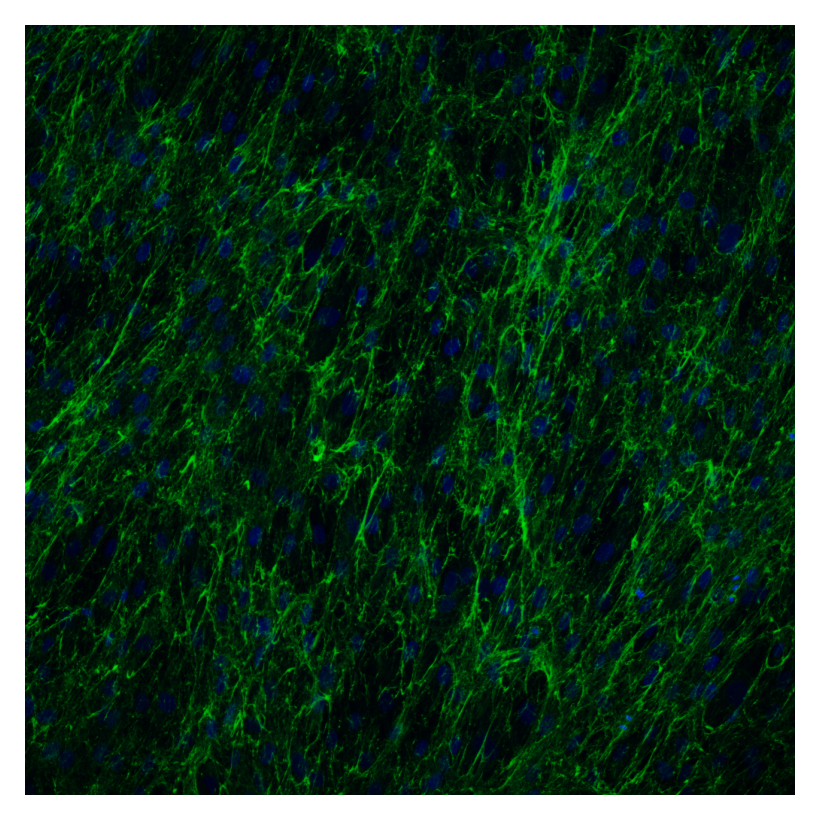

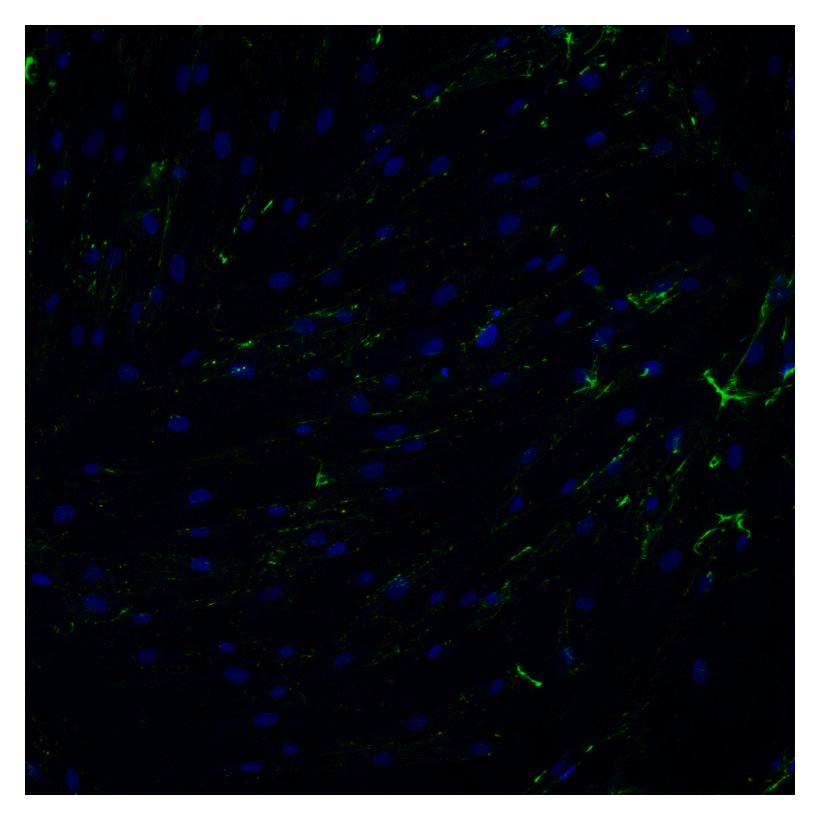

In [65]:
fig, axs = plt.subplots(1,1, figsize = (4,4), dpi = 250)
axs.imshow(images[patient_predicted_control])
axs.axis("off")

fig, axs = plt.subplots(1,1, figsize = (4,4), dpi = 250)
axs.imshow(images[patient_predicted_patient])
axs.axis("off")

In [68]:
x_sample_patient_predicted_control = outputs_processed.iloc[patient_predicted_control:patient_predicted_control+1][X_columns]
x_sample_patient_predicted_patient = outputs_processed.iloc[patient_predicted_patient:patient_predicted_patient+1][X_columns]

In [69]:
print("PATIENT PREDICTED CONTROL: ----")
linear_regression.predict_given_samples(x_sample_patient_predicted_control, verbose = True)
decision_tree.predict_given_samples(x_sample_patient_predicted_control, verbose = True)

print("PATIENT PREDICTED PATIENT : ----")

linear_regression.predict_given_samples(x_sample_patient_predicted_patient, verbose = True)
decision_tree.predict_given_samples(x_sample_patient_predicted_patient, verbose = True)

PATIENT PREDICTED CONTROL: ----
Longitud de las fibras de colágeno estandarizado: 0.0984
Número de agregados de colágeno estandarizado: 1.3
Intensidad media estandarizado: 1.13
Orientación de las fibras estandarizado: 0.336
Número de picos del HOG estandarizado: -0.861
Porosidad estandarizado: 0.651

Predicción: 0.354



Longitud de las fibras de colágeno estandarizado: 0.0984
Número de agregados de colágeno estandarizado: 1.3
Intensidad media estandarizado: 1.13
Orientación de las fibras estandarizado: 0.336
Número de picos del HOG estandarizado: -0.861
Porosidad estandarizado: 0.651

Predicción: 0.11



PATIENT PREDICTED PATIENT : ----
Longitud de las fibras de colágeno estandarizado: -1.8
Número de agregados de colágeno estandarizado: -0.526
Intensidad media estandarizado: -1.91
Orientación de las fibras estandarizado: -1.32
Número de picos del HOG estandarizado: 3.07
Porosidad estandarizado: -1.8

Predicción: 1.33



Longitud de las fibras de colágeno estandarizado: -1.8
Número de 

array([[0.84924846]])